In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import subprocess

In [2]:
IMAGE_PATH = "../dataset/raw/cats/00000006.jpg"  # <-- change this

REAL_ESRGAN_DIR = "./Real-ESRGAN"
MODEL_NAME = "RealESRGAN_x4plus"

OUT_DIR = "./outputs"
os.makedirs(OUT_DIR, exist_ok=True)

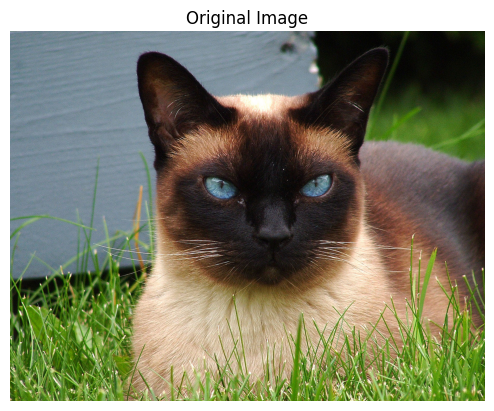

In [3]:
img = Image.open(IMAGE_PATH).convert("RGB")
img_np = np.array(img)

plt.imshow(img_np)
plt.title("Original Image")
plt.axis("off")
plt.show()

In [4]:
def downscale(image, size):
    return image.resize((size, size), Image.BICUBIC)

sizes = [256, 128, 64]

low_res_images = {
    s: downscale(img, s)
    for s in sizes
}

In [5]:
import os
import subprocess
from pathlib import Path

IMG_EXTS = {".png", ".jpg", ".jpeg", ".bmp", ".webp"}

def is_image_file(p):
    return Path(p).suffix.lower() in IMG_EXTS

In [6]:
def get_latest_image(folder):
    folder = Path(folder)

    files = sorted([
        f for f in folder.rglob("*")
        if f.suffix.lower() in [".png", ".jpg", ".jpeg"]
    ])

    if not files:
        raise RuntimeError(f"No output images found in {folder}")

    return files[-1]

In [7]:
import time

def get_output_image(output_path):
    output_path = Path(output_path)

    # wait a bit for filesystem flush (important on macOS)
    for _ in range(10):
        files = sorted([
            f for f in output_path.glob("*")
            if f.suffix.lower() in [".png", ".jpg", ".jpeg"]
        ])
        if files:
            return files[0]
        time.sleep(0.1)

    raise RuntimeError(
        f"No output images found in {output_path}. "
        "Real-ESRGAN likely failed silently."
    )

In [8]:
def run_realesrgan(input_path, output_path, outscale):
    input_path = Path(input_path).resolve()
    output_path = Path(output_path).resolve()

    if not input_path.exists():
        raise FileNotFoundError(f"Input path does not exist: {input_path}")

    output_path.mkdir(parents=True, exist_ok=True)

    cmd = [
        "python",
        "inference_realesrgan.py",
        "-n", MODEL_NAME,
        "-i", str(input_path),
        "-o", str(output_path),
        "--outscale", str(outscale),
        "--fp32"
    ]

    result = subprocess.run(
        cmd,
        cwd=str(Path(REAL_ESRGAN_DIR).resolve()),
        text=True,
        capture_output=True
    )

    # FULL DEBUG OUTPUT
    print("\n===== COMMAND =====")
    print(" ".join(cmd))

    print("\n===== RETURN CODE =====")
    print(result.returncode)

    print("\n===== STDOUT =====")
    print(result.stdout)

    print("\n===== STDERR =====")
    print(result.stderr)

    if result.returncode != 0:
        raise RuntimeError("Real-ESRGAN failed")

    # Real-ESRGAN may append suffixes, so detect generated file
    image_files = sorted([
        f for f in output_path.glob("*")
        if f.suffix.lower() in [".png", ".jpg", ".jpeg", ".webp"]
    ])

    if not image_files:
        raise RuntimeError(
            f"No output images found in {output_path}. "
            f"Check command output above."
        )

    return image_files[0]

In [9]:
def upscale_x8(input_img_path, temp_dir, final_dir):

    os.makedirs(temp_dir, exist_ok=True)
    os.makedirs(final_dir, exist_ok=True)

    # Stage 1: x4
    run_realesrgan(input_img_path, temp_dir, 4)
    temp_img = get_latest_image(temp_dir)

    # Stage 2: x2
    run_realesrgan(temp_img, final_dir, 2)
    final_img = get_latest_image(final_dir)

    return final_img

In [10]:
results = {}

for s, img_lr in low_res_images.items():

    # ---------------------------
    # Define dedicated directories
    # ---------------------------
    lr_dir = os.path.join(OUT_DIR, "lr")
    x4_dir = os.path.join(OUT_DIR, "x4", str(s))
    x8_temp_dir = os.path.join(OUT_DIR, "x8_temp", str(s))
    x8_final_dir = os.path.join(OUT_DIR, "x8", str(s))

    os.makedirs(lr_dir, exist_ok=True)
    os.makedirs(x4_dir, exist_ok=True)
    os.makedirs(x8_temp_dir, exist_ok=True)
    os.makedirs(x8_final_dir, exist_ok=True)

    # ---------------------------
    # Save downscaled LR image
    # ---------------------------
    lr_path = os.path.join(lr_dir, f"lr_{s}.png")
    img_lr.save(lr_path)

    # ---------------------------
    # x4 upscale
    # ---------------------------
    x4_img_path = run_realesrgan(
        input_path=lr_path,
        output_path=x4_dir,
        outscale=4
    )

    # ---------------------------
    # x8 upscale (2-stage)
    # Stage 1: LR -> x4 temp
    # Stage 2: x4 temp -> x8 final
    # ---------------------------
    x8_temp_img_path = run_realesrgan(
        input_path=lr_path,
        output_path=x8_temp_dir,
        outscale=4
    )

    x8_img_path = run_realesrgan(
        input_path=x8_temp_img_path,
        output_path=x8_final_dir,
        outscale=2
    )

    # ---------------------------
    # Store results
    # ---------------------------
    results[s] = {
        "lr": Image.open(lr_path).copy(),
        "x4": Image.open(x4_img_path).copy(),
        "x8": Image.open(x8_img_path).copy(),
    }


===== COMMAND =====
python inference_realesrgan.py -n RealESRGAN_x4plus -i /Users/artemvolosevich/Documents/ITMO/Second Term/man-to-cat-2026/upscaling/outputs/lr/lr_256.png -o /Users/artemvolosevich/Documents/ITMO/Second Term/man-to-cat-2026/upscaling/outputs/x4/256 --outscale 4 --fp32

===== RETURN CODE =====
0

===== STDOUT =====
Testing 0 lr_256


===== STDERR =====
/Users/artemvolosevich/Documents/ITMO/Second Term/man-to-cat-2026/.venv/lib/python3.10/site-packages/torchvision/transforms/functional_tensor.py:5: UserWarning: The torchvision.transforms.functional_tensor module is deprecated in 0.15 and will be **removed in 0.17**. Please don't rely on it. You probably just need to use APIs in torchvision.transforms.functional or in torchvision.transforms.v2.functional.
  warnings.warn(
libpng warning: iCCP: known incorrect sRGB profile


===== COMMAND =====
python inference_realesrgan.py -n RealESRGAN_x4plus -i /Users/artemvolosevich/Documents/ITMO/Second Term/man-to-cat-2026/upscali

RuntimeError: Real-ESRGAN failed

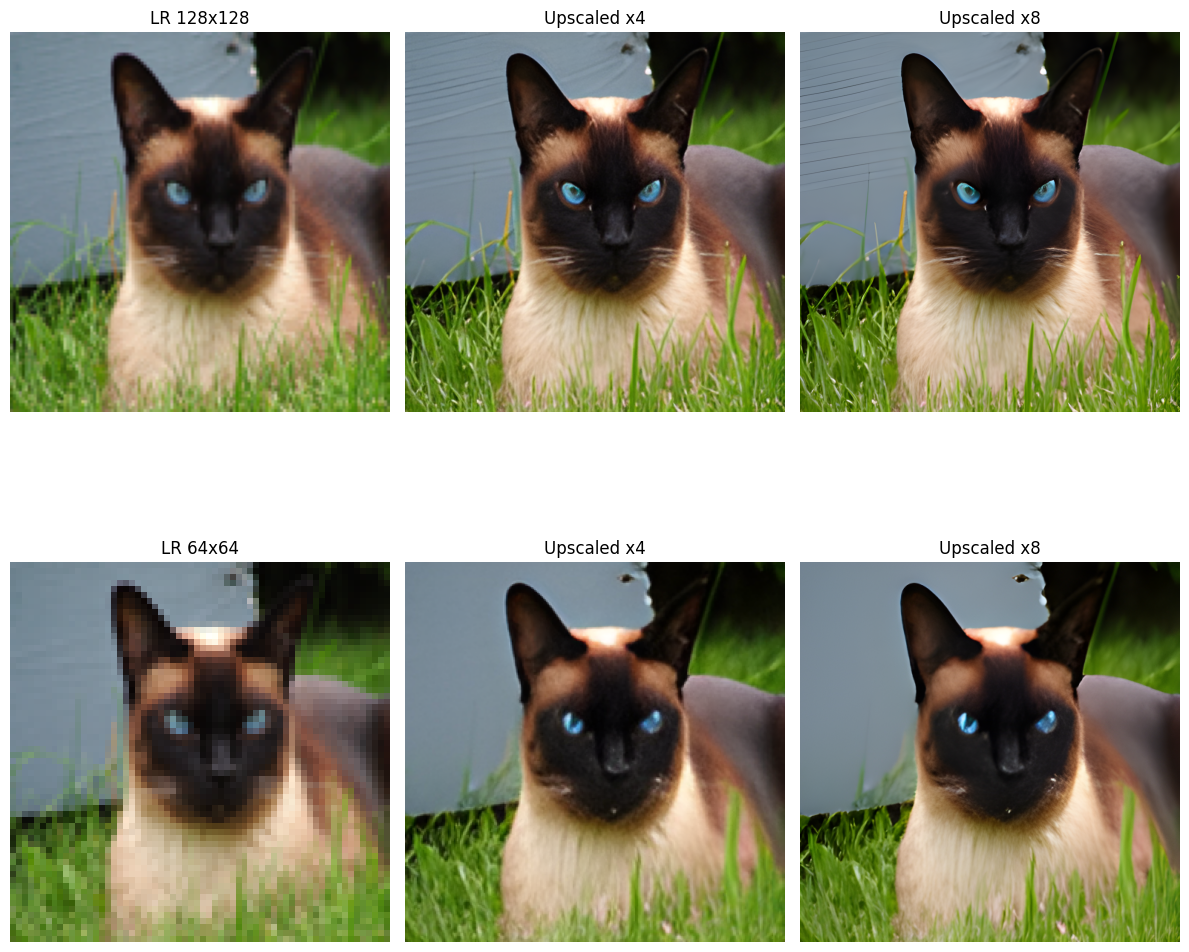

In [ ]:
fig, axes = plt.subplots(len(sizes), 3, figsize=(12, 12))

for i, s in enumerate(sizes):
    axes[i, 0].imshow(results[s]["lr"])
    axes[i, 0].set_title(f"LR {s}x{s}")

    axes[i, 1].imshow(results[s]["x4"])
    axes[i, 1].set_title("Upscaled x4")

    axes[i, 2].imshow(results[s]["x8"])
    axes[i, 2].set_title("Upscaled x8")

    for j in range(3):
        axes[i, j].axis("off")

plt.tight_layout()
plt.show()